# Revenue Classification - Amazon Sales Dataset

## Objective
Build a classification model to predict whether an order will generate **high or low revenue**, based on product characteristics available before the sale.

## Target variable
- `1` = high revenue (above the dataset mean)
- `0` = low revenue (below the dataset mean)

## Features used
- `price`: original product price
- `discount_percent`: discount percentage applied
- `rating`: product rating
- `review_count`: number of reviews

**Note:** `quantity_sold` was intentionally excluded from the features. Since `total_revenue = price * (1 - discount/100) * quantity_sold`, including it would allow the model to reconstruct the target mathematically, causing data leakage and artificially perfect results.

## Algorithm
RandomForestClassifier — an ensemble of decision trees that votes on the final prediction, making it more robust than a single tree.

## 1. Imports and data loading

Loading all necessary libraries and the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv("amazon_sales_dataset.csv")
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


## 2. Statistical summary

Descriptive statistics for numeric columns. Useful to understand the scale of each variable and identify potential outliers before modeling.

In [2]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


## 3. Data cleaning

Filling missing values with 0 to ensure the model does not receive null data.

In [3]:
df = df.fillna(0)
print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


## 4. Creating the target variable

Instead of predicting the exact revenue value, we classify each order as high or low revenue:
- `1` = `total_revenue` is above the dataset mean
- `0` = `total_revenue` is below the dataset mean

This transforms the problem from regression into binary classification.

In [4]:
mean_revenue = df["total_revenue"].mean()
df["high_revenue"] = (df["total_revenue"] > mean_revenue).astype(int)

print(f"Mean total revenue: {mean_revenue:.2f}")
print(f"\nClass distribution:")
print(df["high_revenue"].value_counts())

Mean total revenue: 657.33

Class distribution:
high_revenue
0    29633
1    20367
Name: count, dtype: int64


## 5. Class distribution

Checking whether the classes are balanced. A large imbalance between classes can bias the model toward the majority class.

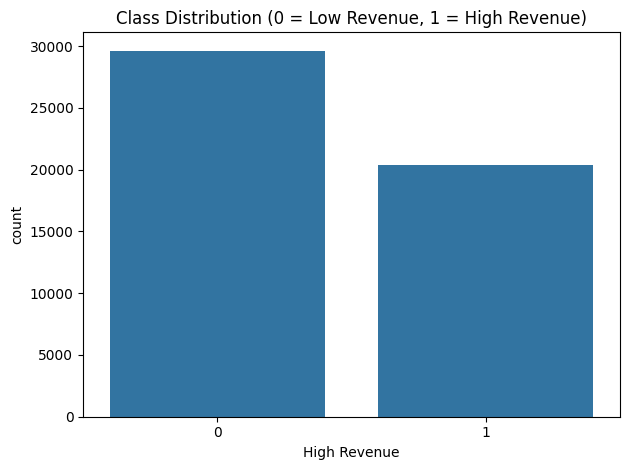

In [5]:
sns.countplot(x="high_revenue", data=df)
plt.title("Class Distribution (0 = Low Revenue, 1 = High Revenue)")
plt.xlabel("High Revenue")
plt.tight_layout()
plt.show()

## 6. Feature and target definition

Selecting only features that are available before the sale and independent from the target.

`quantity_sold` was excluded because it directly determines `total_revenue`, causing data leakage.

In [6]:
X = df[["price", "discount_percent", "rating", "review_count"]]
y = df["high_revenue"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (50000, 4)
Target shape: (50000,)


## 7. Train/test split

Splitting the data into 80% for training and 20% for testing. `random_state=42` ensures the split is reproducible across runs. `stratify=y` keeps the same class proportion in both train and test sets.

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", x_train.shape)
print("Test: ", x_test.shape)

Train: (40000, 4)
Test:  (10000, 4)


## 8. Model training

Training a `RandomForestClassifier` with 100 decision trees. Each tree is trained on a random subset of the data, and the final prediction is the majority vote across all trees.

In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

## 9. Prediction

In [9]:
pred = model.predict(x_test)

## 10. Model evaluation

- **Accuracy:** percentage of correct predictions overall
- **Precision:** of all orders predicted as high revenue, how many actually were
- **Recall:** of all actual high revenue orders, how many the model correctly identified
- **F1-score:** harmonic mean of precision and recall — useful when classes are imbalanced

In [10]:
accuracy  = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall    = recall_score(y_test, pred)
f1        = f1_score(y_test, pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, pred, target_names=["Low Revenue", "High Revenue"]))

Accuracy:  0.7561
Precision: 0.6821
Recall:    0.7513
F1-Score:  0.7150

Classification Report:
              precision    recall  f1-score   support

 Low Revenue       0.82      0.76      0.79      5927
High Revenue       0.68      0.75      0.72      4073

    accuracy                           0.76     10000
   macro avg       0.75      0.76      0.75     10000
weighted avg       0.76      0.76      0.76     10000



## 11. Confusion matrix

The confusion matrix shows how many predictions were correct and where the model made mistakes:
- **True Positives (TP):** correctly predicted high revenue
- **True Negatives (TN):** correctly predicted low revenue
- **False Positives (FP):** predicted high revenue but was actually low
- **False Negatives (FN):** predicted low revenue but was actually high

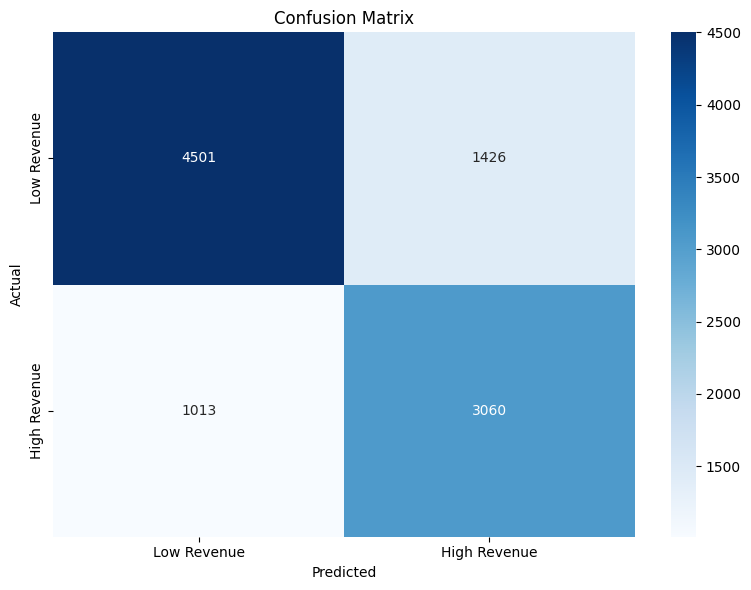

In [11]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low Revenue", "High Revenue"],
            yticklabels=["Low Revenue", "High Revenue"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 12. Feature importance

Which features the model considered most relevant for classifying revenue as high or low. Higher importance means the feature had more influence on the model's decisions.

price               0.622395
review_count        0.209734
rating              0.126312
discount_percent    0.041559
dtype: float64


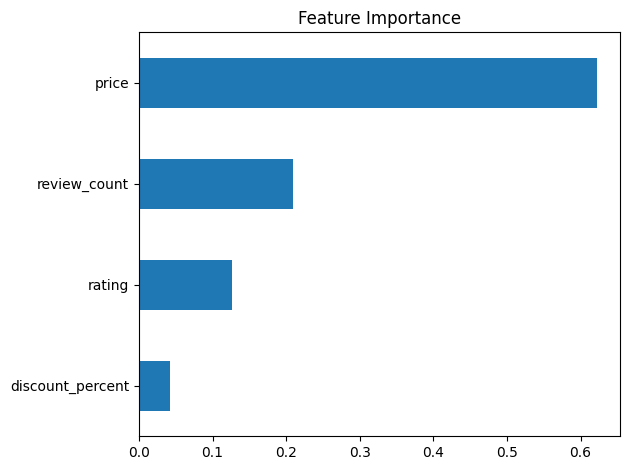

In [12]:
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

## Conclusions

- Orders were classified as high or low revenue based on whether they exceeded the dataset mean.
- `quantity_sold` was excluded from features to avoid data leakage, since it directly determines `total_revenue`.
- The RandomForestClassifier was trained with 100 trees using 4 independent features.
- The confusion matrix shows the exact number of correct and incorrect predictions for each class.
- Feature importance reveals which product characteristics most influence whether an order generates high or low revenue.